# Time- and Space-Averaged Lid-Drag Optimization

This notebook samples a lid-velocity control from a sine wave shifted by `+1.5`, then optimizes the sampled values to reduce the time-average of the spatially averaged lid shear.

## 0 · Notebook Loader

In [1]:
import json
from pathlib import Path

def run_notebook_cells(path, stop_on=None):
    candidate = Path(path)
    if not candidate.exists():
        candidate = Path("jax") / path

    with open(candidate) as f:
        nb = json.load(f)

    ns = {}
    for i, cell in enumerate(nb["cells"]):
        if cell["cell_type"] != "code":
            continue

        src = "".join(cell["source"])
        src = "\n".join(
            line for line in src.splitlines()
            if not line.strip().startswith("%")
        )

        if stop_on and stop_on in src:
            print(f"  Stopped before cell {i} (trigger: '{stop_on}')")
            break

        try:
            exec(src, ns)
        except Exception as e:
            print(f"  Cell {i} skipped - {type(e).__name__}: {e}")

    return ns


## 1 · Import from the JAX Solver Notebook

In [2]:
print("Loading cavity_flow_jax.ipynb ...")
jax_ns = run_notebook_cells(
    "cavity_flow_jax.ipynb",
    stop_on="u_sol, v_sol, p_sol = cavity_flow",
)

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

build_up_b = jax_ns["build_up_b"]
pressure_poisson = jax_ns["pressure_poisson"]

nx = jax_ns["nx"]
ny = jax_ns["ny"]
nt = jax_ns["nt"]
dx = jax_ns["dx"]
dy = jax_ns["dy"]
rho = jax_ns["rho"]
nu = jax_ns["nu"]
dt = jax_ns["dt"]
X = jax_ns["X"]
Y = jax_ns["Y"]

print(f"Imported grid: nx={nx}, ny={ny}, nt={nt}")
print(f"Physics: rho={rho}, nu={nu}, dt={dt}, dx={dx}, dy={dy}")


Loading cavity_flow_jax.ipynb ...
  Stopped before cell 5 (trigger: 'u_sol, v_sol, p_sol = cavity_flow')
Imported grid: nx=41, ny=41, nt=1000
Physics: rho=1.0, nu=0.1, dt=0.001, dx=0.025, dy=0.025


## 2 · Time-Dependent Simulator with Running Drag Accumulation

In [3]:
def top_wall_shear(u):
    return (u[:, -1] - u[:, -2]) / dy


def step_fn(carry, a_i):
    """Advance one timestep and accumulate the spatially averaged lid drag."""
    u, v, p, l_tot = carry

    b = build_up_b(jnp.zeros((nx, ny)), rho, dt, u, v, dx, dy)
    p = pressure_poisson(p, dx, dy, b)

    un, vn = u, v

    u = u.at[1:-1, 1:-1].set(
        un[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt / dx * (un[1:-1, 1:-1] - un[0:-2, 1:-1])
        - vn[1:-1, 1:-1] * dt / dy * (un[1:-1, 1:-1] - un[1:-1, 0:-2])
        - dt / (2 * rho * dx) * (p[2:, 1:-1] - p[0:-2, 1:-1])
        + nu * (
            dt / dx**2 * (un[2:, 1:-1] - 2 * un[1:-1, 1:-1] + un[0:-2, 1:-1])
            + dt / dy**2 * (un[1:-1, 2:] - 2 * un[1:-1, 1:-1] + un[1:-1, 0:-2])
        )
    )

    v = v.at[1:-1, 1:-1].set(
        vn[1:-1, 1:-1]
        - un[1:-1, 1:-1] * dt / dx * (vn[1:-1, 1:-1] - vn[0:-2, 1:-1])
        - vn[1:-1, 1:-1] * dt / dy * (vn[1:-1, 1:-1] - vn[1:-1, 0:-2])
        - dt / (2 * rho * dy) * (p[1:-1, 2:] - p[1:-1, 0:-2])
        + nu * (
            dt / dx**2 * (vn[2:, 1:-1] - 2 * vn[1:-1, 1:-1] + vn[0:-2, 1:-1])
            + dt / dy**2 * (vn[1:-1, 2:] - 2 * vn[1:-1, 1:-1] + vn[1:-1, 0:-2])
        )
    )

    u = u.at[:, 0].set(0.0)
    u = u.at[0, :].set(0.0)
    u = u.at[-1, :].set(0.0)
    u = u.at[:, -1].set(a_i)

    v = v.at[:, 0].set(0.0)
    v = v.at[:, -1].set(0.0)
    v = v.at[0, :].set(0.0)
    v = v.at[-1, :].set(0.0)

    du_dy = top_wall_shear(u)
    l_curr = jnp.mean(jnp.abs(du_dy))
    l_tot = l_tot + l_curr

    return (u, v, p, l_tot), du_dy


def run_sim(a):
    """Run the full simulation and return the final state and average lid drag."""
    u0 = jnp.zeros((nx, ny))
    v0 = jnp.zeros((nx, ny))
    p0 = jnp.zeros((nx, ny))
    l0 = 0.0
    (u_f, v_f, p_f, l_tot), du_dy_history = jax.lax.scan(step_fn, (u0, v0, p0, l0), a)
    l_avg = l_tot / nt
    return u_f, v_f, p_f, l_avg, du_dy_history


print("step_fn and run_sim defined.")


step_fn and run_sim defined.


## 3 · Initial Lid Control: sin(phase) + 1.5

In [4]:
t = jnp.arange(nt) * dt
total_time = nt * dt
phase = 2.0 * jnp.pi * t / total_time
a_min = 0.5
a_max = 2.5
a0 = jnp.sin(phase) + 1.5

print(f"a0 shape: {a0.shape}")
print(f"a0 min/max: {float(jnp.min(a0)):.6f}, {float(jnp.max(a0)):.6f}")
print(f"Control bounds enforced during optimization: [{a_min:.3f}, {a_max:.3f}]")
print(f"Initial control completes one sine-wave cycle over T={total_time:.3f} seconds")


a0 shape: (1000,)
a0 min/max: 0.500000, 2.500000
Control bounds enforced during optimization: [0.500, 2.500]
Initial control completes one sine-wave cycle over T=1.000 seconds


## 4 · Time-Averaged Drag Loss and Gradient

In [5]:
def loss(a):
    u_f, v_f, p_f, l_avg, du_dy_history = run_sim(a)
    return l_avg


grad_fn = jax.jit(jax.value_and_grad(loss))

print("Loss and gradient function compiled.")
print("The first call will include JAX compilation time.")


Loss and gradient function compiled.
The first call will include JAX compilation time.


## 5 · Quick Validation Pass

In [6]:
u_test, v_test, p_test, l_avg0, du_dy_hist0 = run_sim(a0)
loss0, grad0 = grad_fn(a0)

print(f"u_test shape: {u_test.shape}, finite={bool(jnp.isfinite(u_test).all())}")
print(f"v_test shape: {v_test.shape}, finite={bool(jnp.isfinite(v_test).all())}")
print(f"p_test shape: {p_test.shape}, finite={bool(jnp.isfinite(p_test).all())}")
print(f"du_dy history shape: {du_dy_hist0.shape}")
print(f"Initial time-avg drag: {float(l_avg0):.6f}")
print(f"grad shape: {grad0.shape}")
print(f"grad L2 norm: {float(jnp.linalg.norm(grad0)):.6e}")
print(f"nonzero gradient: {bool(jnp.any(jnp.abs(grad0) > 0))}")


u_test shape: (41, 41), finite=True
v_test shape: (41, 41), finite=True
p_test shape: (41, 41), finite=True
du_dy history shape: (1000, 41)
Initial time-avg drag: 19.144043
grad shape: (1000,)
grad L2 norm: 4.128801e-01
nonzero gradient: True


## 6 · Gradient-Based Optimization

In [7]:
a = a0
lr = 1e-2
n_iters = 150
beta1 = 0.9
beta2 = 0.999
eps = 1e-8
m = jnp.zeros_like(a)
v = jnp.zeros_like(a)

loss_history = []
grad_norm_history = []

for i in range(1, n_iters + 1):
    val, grads = grad_fn(a)
    if not bool(jnp.isfinite(val)) or not bool(jnp.isfinite(grads).all()):
        print(f"Stopping early at iter {i - 1}: encountered non-finite loss/gradient")
        break
    m = beta1 * m + (1.0 - beta1) * grads
    v = beta2 * v + (1.0 - beta2) * (grads ** 2)
    m_hat = m / (1.0 - beta1 ** i)
    v_hat = v / (1.0 - beta2 ** i)
    a = a - lr * m_hat / (jnp.sqrt(v_hat) + eps)
    a = jnp.clip(a, a_min, a_max)

    loss_history.append(float(val))
    grad_norm_history.append(float(jnp.linalg.norm(grads)))

    if (i - 1) % 25 == 0:
        print(f"iter {i - 1:3d}  loss={float(val):.6f}  |grad|={float(jnp.linalg.norm(grads)):.4e}")

print("Optimization complete.")


iter   0  loss=19.144043  |grad|=4.1288e-01
iter  25  loss=16.407345  |grad|=4.1075e-01
iter  50  loss=14.076807  |grad|=4.1030e-01
iter  75  loss=12.049360  |grad|=4.1012e-01
iter 100  loss=10.320620  |grad|=4.1023e-01
iter 125  loss=8.899845  |grad|=4.1049e-01
Optimization complete.


## 7 · Results

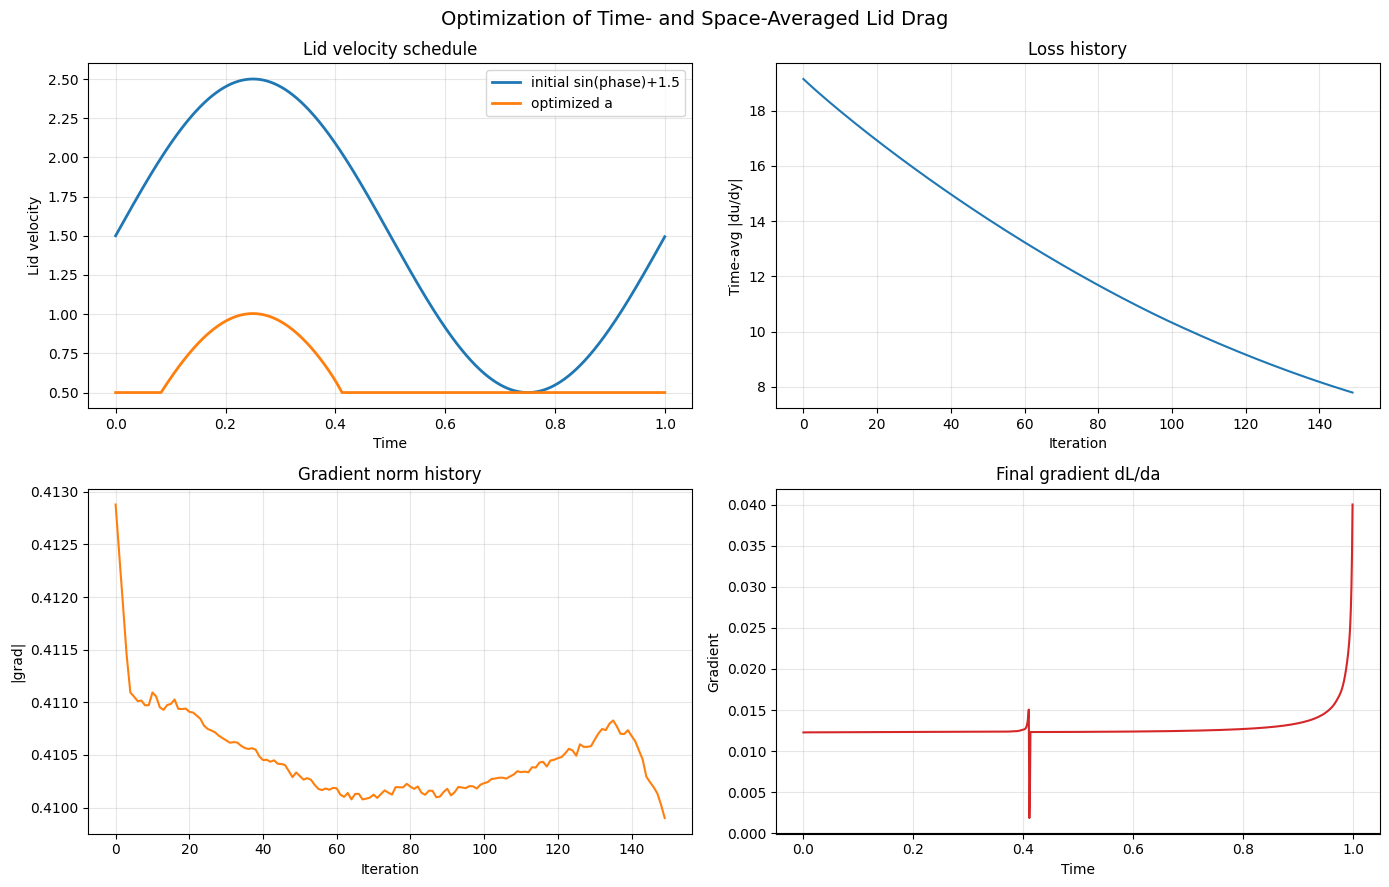

Initial loss: 19.144043
Final loss:   7.749617
Max |a - a0|: 1.526461
Optimized control range: [0.500000, 1.003832]


In [8]:
final_loss, final_grads = grad_fn(a)
u_opt, v_opt, p_opt, l_avg_opt, du_dy_hist_opt = run_sim(a)
control_delta = a - a0
spatial_drag_hist_opt = jnp.mean(jnp.abs(du_dy_hist_opt), axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Optimization of Time- and Space-Averaged Lid Drag", fontsize=14)

axes[0, 0].plot(np.array(t), np.array(a0), label="initial sin(phase)+1.5", linewidth=2)
axes[0, 0].plot(np.array(t), np.array(a), label="optimized a", linewidth=2)
axes[0, 0].set_title("Lid velocity schedule")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Lid velocity")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(loss_history, color="tab:blue")
axes[0, 1].set_title("Loss history")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Time-avg |du/dy|")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(grad_norm_history, color="tab:orange")
axes[1, 0].set_title("Gradient norm history")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("|grad|")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(np.array(t), np.array(final_grads), color="tab:red")
axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
axes[1, 1].set_title("Final gradient dL/da")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Gradient")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss:   {float(final_loss):.6f}")
print(f"Max |a - a0|: {float(jnp.max(jnp.abs(control_delta))):.6f}")
print(f"Optimized control range: [{float(jnp.min(a)):.6f}, {float(jnp.max(a)):.6f}]")


## 8 · Initial vs Optimized Lid Velocity

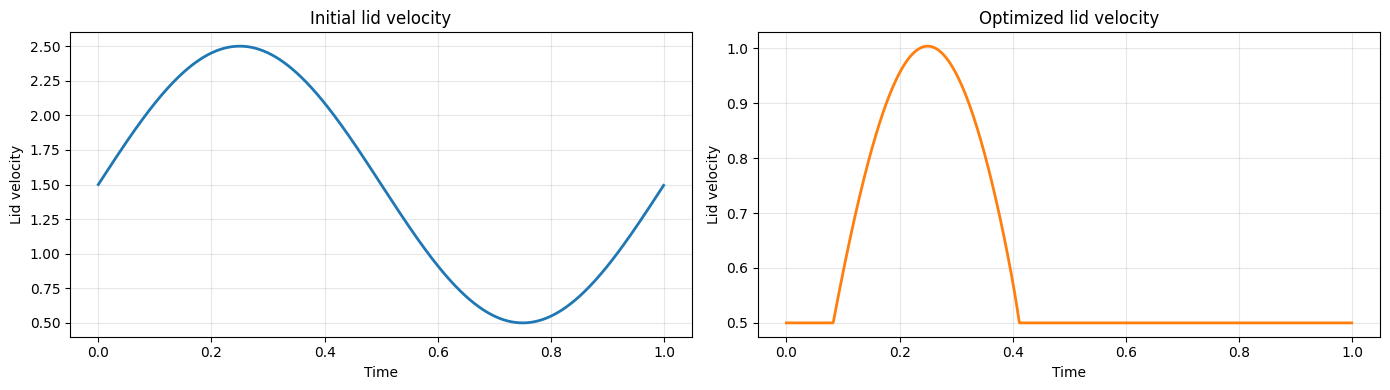

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

axes[0].plot(np.array(t), np.array(a0), linewidth=2)
axes[0].set_title("Initial lid velocity")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Lid velocity")
axes[0].grid(alpha=0.3)

axes[1].plot(np.array(t), np.array(a), linewidth=2, color="tab:orange")
axes[1].set_title("Optimized lid velocity")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Lid velocity")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9 · Drag History and Final Flow

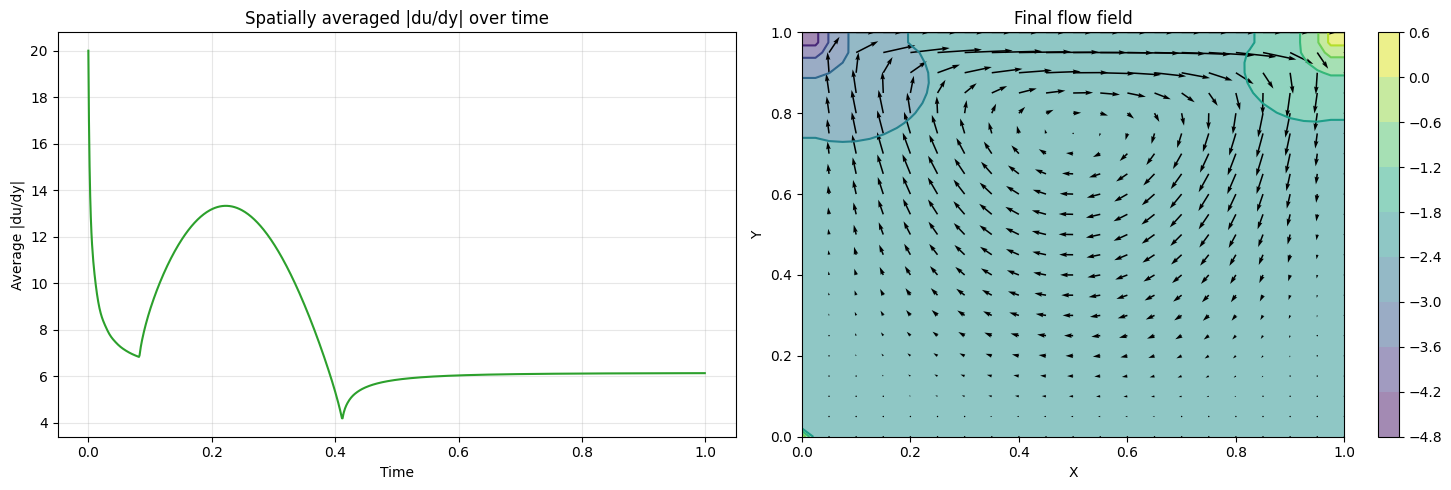

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(np.array(t), np.array(spatial_drag_hist_opt), color="tab:green")
axes[0].set_title("Spatially averaged |du/dy| over time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Average |du/dy|")
axes[0].grid(alpha=0.3)

cf = axes[1].contourf(np.array(X), np.array(Y), np.array(p_opt), alpha=0.5, cmap="viridis")
fig.colorbar(cf, ax=axes[1])
axes[1].contour(np.array(X), np.array(Y), np.array(p_opt), cmap="viridis")
axes[1].quiver(
    np.array(X)[::2, ::2],
    np.array(Y)[::2, ::2],
    np.array(u_opt)[::2, ::2],
    np.array(v_opt)[::2, ::2],
)
axes[1].set_title("Final flow field")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

plt.tight_layout()
plt.show()
